In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


2026-03-18 07:20:18.933577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773818419.164813      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773818419.231107      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Load & Prepare Data**

In [2]:
data_dir = '/kaggle/input/brain-tumor-detection'
groups = ['yes', 'no']
file_paths = []
labels = []

for group in groups:
    fold_path = os.path.join(data_dir, group) 
    files = os.listdir(fold_path)
    for file in files:
        file_path = os.path.join(fold_path, file)
        file_paths.append(file_path)
        labels.append(group)


In [3]:
df=pd.DataFrame({'file_paths':file_paths,
                'labels':labels})

print(df.sample(10))

print(df['labels'].value_counts())


                                             file_paths labels
1918  /kaggle/input/brain-tumor-detection/no/no1445.jpg     no
929      /kaggle/input/brain-tumor-detection/yes/y2.jpg    yes
2158   /kaggle/input/brain-tumor-detection/no/no440.jpg     no
486    /kaggle/input/brain-tumor-detection/yes/y666.jpg    yes
2334  /kaggle/input/brain-tumor-detection/no/no1023.jpg     no
2072   /kaggle/input/brain-tumor-detection/no/no586.jpg     no
1859  /kaggle/input/brain-tumor-detection/no/no1373.jpg     no
462   /kaggle/input/brain-tumor-detection/yes/y1292.jpg    yes
1650  /kaggle/input/brain-tumor-detection/no/no1164.jpg     no
263   /kaggle/input/brain-tumor-detection/yes/y1181.jpg    yes
labels
yes    1500
no     1500
Name: count, dtype: int64


**Train/Test Split**

In [4]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['labels'])

**Image Data Generator**

In [5]:
gen=ImageDataGenerator()
train_gen=gen.flow_from_dataframe(train_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)

test_gen=gen.flow_from_dataframe(test_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)


Found 2400 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.


**Build and Compile CNN Model**

In [6]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773818444.745475      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773818444.748315      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


**Training**

In [7]:
traning = model.fit(train_gen, epochs=35, validation_data=test_gen)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35


I0000 00:00:1773818450.030242     105 service.cc:148] XLA service 0x4af1b840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773818450.031529     105 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773818450.031585     105 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773818450.519637     105 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/150 ━━━━━━━━━━━━━━━━━━━━ 22:53 9s/step - accuracy: 0.4375 - loss: 15.6554

I0000 00:00:1773818455.671381     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.6792 - loss: 17.1421 - val_accuracy: 0.7567 - val_loss: 0.4870
Epoch 2/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7889 - loss: 0.4396 - val_accuracy: 0.7967 - val_loss: 0.4804
Epoch 3/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7819 - loss: 0.4527 - val_accuracy: 0.8583 - val_loss: 0.3219
Epoch 4/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8007 - loss: 0.4318 - val_accuracy: 0.8667 - val_loss: 0.3115
Epoch 5/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.8422 - loss: 0.3510 - val_accuracy: 0.8617 - val_loss: 0.3103
Epoch 6/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8842 - loss: 0.2926 - val_accuracy: 0.9400 - val_loss: 0.2192
Epoch 7/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8969 - loss: 0.2683 - val_accuracy: 0.9333 - val_loss: 0.1595
Epoch 8/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9234 - loss: 0.2146 - val_accuracy: 0.

In [8]:
model.evaluate(train_gen)

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 1.0000 - loss: 0.0020


[0.0019470039987936616, 1.0]

In [9]:
model.evaluate(test_gen)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9883 - loss: 0.0648


[0.06875092536211014, 0.9866666793823242]

**Performance Visualization**

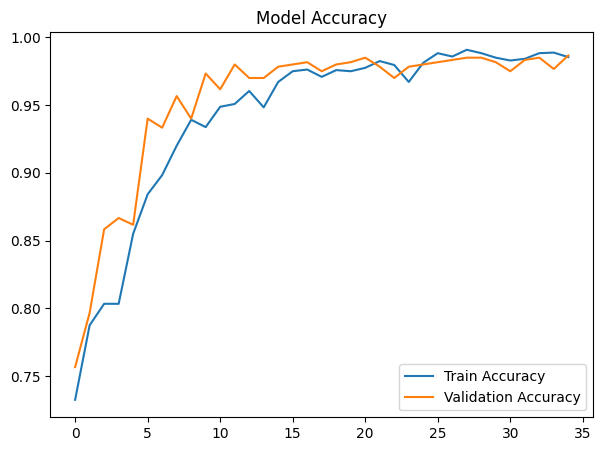

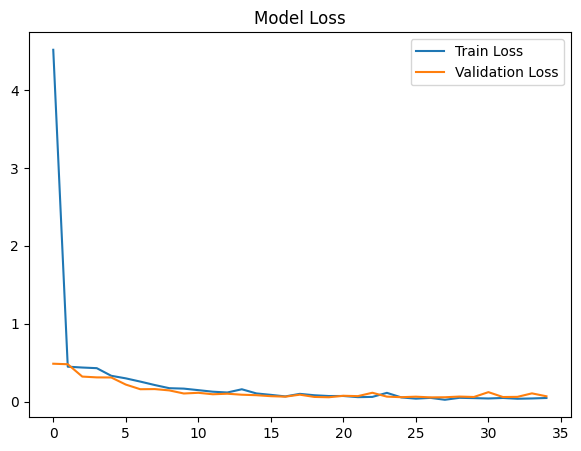

In [10]:
plt.figure(figsize=(7,5))
plt.plot(traning.history['accuracy'], label='Train Accuracy')
plt.plot(traning.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(traning.history['loss'], label='Train Loss')
plt.plot(traning.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


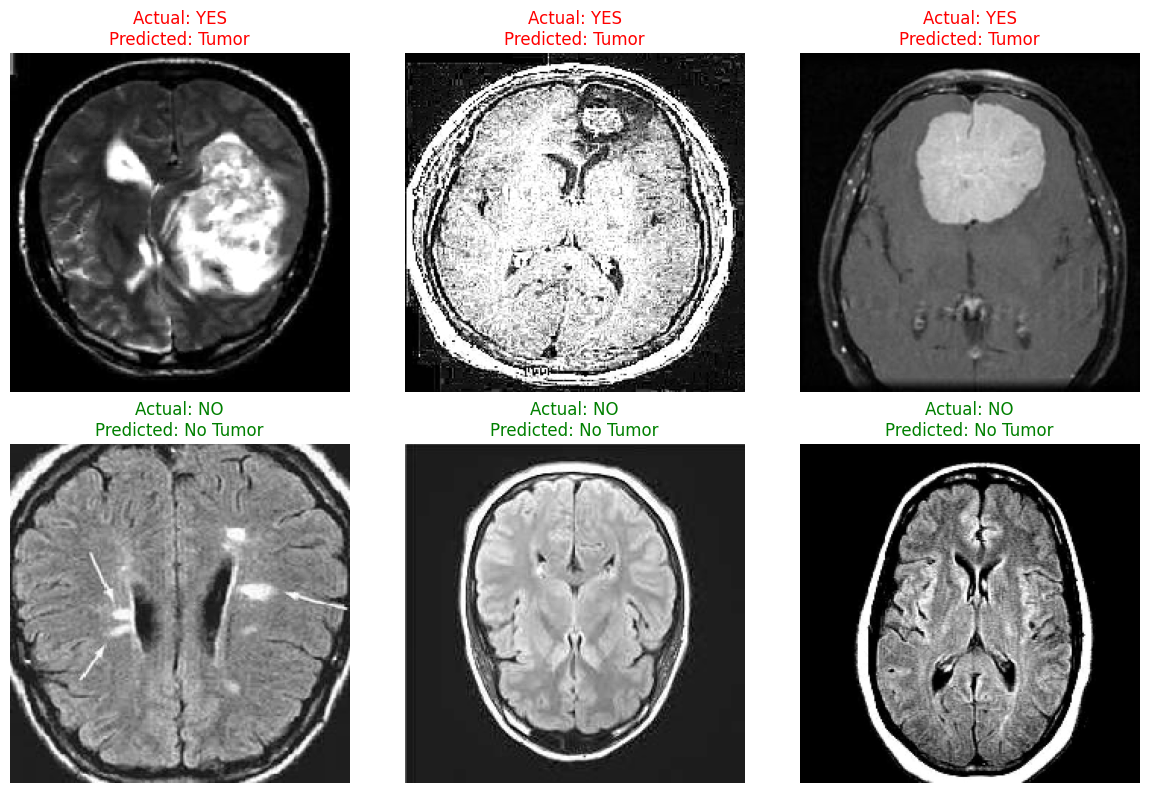

In [11]:
import random
from tensorflow.keras.preprocessing import image

def show_prediction(folder, filename):
    img_path = os.path.join(data_dir, folder, filename)
    img = image.load_img(img_path, target_size=(224,224), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        result = "Tumor"
        color = "red"
    else:
        result = "No Tumor"
        color = "green"

    plt.imshow(np.array(img).squeeze(), cmap='gray')
    plt.title(f"Actual: {folder.upper()}\nPredicted: {result}", color=color)
    plt.axis('off')


yes_images = random.sample(os.listdir(os.path.join(data_dir, 'yes')), 3)
no_images  = random.sample(os.listdir(os.path.join(data_dir, 'no')), 3)


plt.figure(figsize=(12, 8))

for i, img_name in enumerate(yes_images):
    plt.subplot(2, 3, i + 1)
    show_prediction('yes', img_name)

for i, img_name in enumerate(no_images):
    plt.subplot(2, 3, i + 4)
    show_prediction('no', img_name)

plt.tight_layout()
plt.show()

**Save Model**

In [12]:
model.save("brain_tumor_model.h5")